# xG Prediction

### Imports and loading

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR = Path().resolve().parent / "Additional"
df = pd.read_parquet(DATA_DIR / "for_regression.parquet")
print(df.head(10))
print(df.shape)
print(list(df.columns))

print(f"Unique match,team,period, possession combos: {df.groupby(['match_id','OFF_TEAM_ID','period','possession']).ngroups}")
print(f"Total rows: {len(df)}")
print(f"\ntotal_xg stats:")
print(df['total_xg'].describe())
print(f"\nn_shots stats:")
print(df['n_shots'].describe())
print(f"\nRows per match_id (sample):")
print(df.groupby('match_id').size().describe())

shot_df = df[df['n_shots'] > 0]
print(f"Shot-producing rows: {len(shot_df)}")
print(f"Shot rate: {len(shot_df)/len(df):.4f}")
print(f"\ntotal_xg on shot rows:")
print(shot_df['total_xg'].describe())

print(f"\nlog_xg mean: {np.log(shot_df['total_xg']).mean():.4f}")
print(f"log_xg skewness: {np.log(shot_df['total_xg']).skew():.4f}")

   match_id           possession_type  period  possession  OFF_TEAM_ID  \
0   3825722   Attacking Third - Short       2         145         1041   
1   3754346  Defensive Third - Direct       2         111           36   
2   3754256     Middle Third - Direct       1          36           39   
3   3857290   Attacking Third - Short       2         174         2722   
4   3893793     Middle Third - Direct       2         196         1210   
5   3829428     Middle Third - Direct       1          44          130   
6   3879554      Middle Third - Short       2         187         2256   
7    303479     Middle Third - Direct       1          54          210   
8   3754339      Middle Third - Short       2         136           30   
9      7572      Middle Third - Short       1          52          778   

  OFF_MEN_WOMEN  OFF_BACKS  OFF_MIDFIELDERS  OFF_FORWARDS  OFF_GOALKEEPER  \
0             M        4.0              4.0           2.0             1.0   
1             M        4.0     

### Data Prep

In [3]:
shot_df = df[df['n_shots'] > 0].copy()
shot_df['log_xg'] = np.log(shot_df['total_xg'])
df_model = pd.get_dummies(shot_df, columns=['possession_type'], drop_first=True)
df_model['IS_MENS'] = (df_model['OFF_MEN_WOMEN'] == 'M').astype(int)

for c in ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes', 'IS_MENS',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C4', 'DIFF_C5',
     'DIFF_GK_C0', 'DIFF_GK_C1']  # DIFF_GK_C2 dropped as implicit reference
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

print(f"Shape: {df_model.shape}")
print(f"Nulls: {df_model[feature_cols + ['log_xg']].isnull().sum().sum()}")
print(f"log_xg mean: {df_model['log_xg'].mean():.4f}, std: {df_model['log_xg'].std():.4f}")

Shape: (77428, 56)
Nulls: 0
log_xg mean: -2.8098, std: 1.1290


### Multicollinearity check

In [5]:
X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string())
print(f"Shape: {df_model.shape}")

                                      feature       VIF
1                                     IS_MENS  4.959329
8                                  DIFF_GK_C1  2.738424
7                                  DIFF_GK_C0  2.097672
5                                     DIFF_C4  2.084658
9     possession_type_Attacking Third - Short  1.933469
10   possession_type_Defensive Third - Direct  1.843478
6                                     DIFF_C5  1.747120
4                                     DIFF_C2  1.703298
2                                     DIFF_C0  1.681788
12    possession_type_Defensive Third - Short  1.670070
13      possession_type_Middle Third - Direct  1.608816
0                            duration_minutes  1.536814
15       possession_type_Middle Third - Short  1.491908
3                                     DIFF_C1  1.410387
14     possession_type_Middle Third - Patient  1.279658
11  possession_type_Defensive Third - Patient  1.038331
Shape: (77428, 56)


### Train/Test and Scaling

In [6]:
X = df_model[feature_cols].astype(float)
y = df_model['log_xg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Fit

In [7]:
# sklearn for performance metrics
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")
print(f"RMSE (xg scale, approx): {np.exp(rmse):.4f}")

R²: 0.0160
RMSE (log scale): 1.1303
RMSE (xg scale, approx): 3.0966


### Inference

In [8]:
# statsmodels for inference
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm)
result = ols_model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 log_xg   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     57.45
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          5.74e-184
Time:                        21:51:27   Log-Likelihood:                -94804.
No. Observations:               61942   AIC:                         1.896e+05
Df Residuals:                   61925   BIC:                         1.898e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8112      0.004   -625.687      0.0

### Add variable names back

In [9]:
feature_names = ['const'] + feature_cols
results_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'exp_coef': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('exp_coef', ascending=False)
print(results_df.to_string())

                                     variable  coefficient  exp_coef       p_value
6                                     DIFF_C4     0.098755  1.103796  1.445797e-51
4                                     DIFF_C1     0.070861  1.073432  3.230189e-40
9                                  DIFF_GK_C1     0.067093  1.069395  1.156609e-19
3                                     DIFF_C0     0.061063  1.062966  7.240608e-26
8                                  DIFF_GK_C0     0.054110  1.055601  8.081393e-17
5                                     DIFF_C2     0.024292  1.024589  2.985875e-05
14      possession_type_Middle Third - Direct     0.022467  1.022721  2.127633e-03
10    possession_type_Attacking Third - Short     0.017636  1.017792  3.551805e-02
1                            duration_minutes     0.017574  1.017730  3.528507e-04
13    possession_type_Defensive Third - Short     0.011664  1.011732  1.276539e-01
7                                     DIFF_C5     0.010044  1.010095  9.145212e-02
11  

### Cross Validation

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
print(f"\nCV R² scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV R² scores: [0.01156041 0.01130575 0.01866529 0.01547723 0.01376287]
Mean: 0.0142 (+/- 0.0027)


### Results and Viz

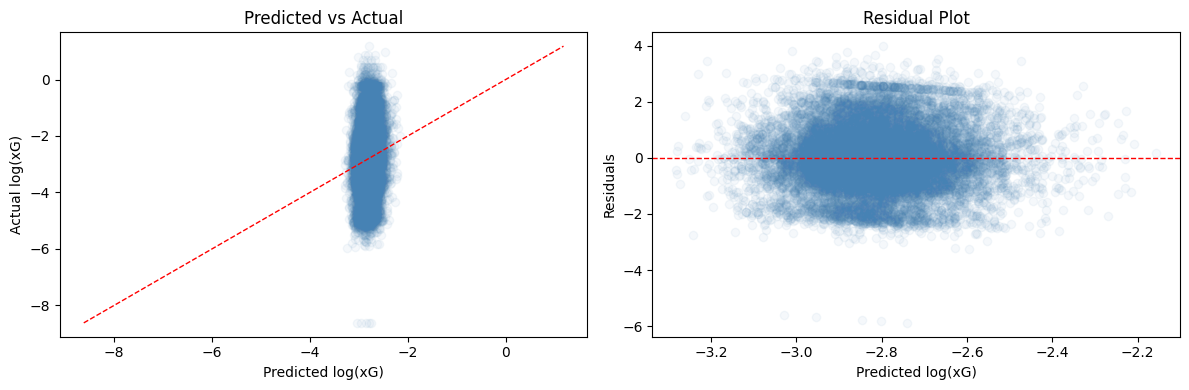

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, y_test, alpha=0.05, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=1)
axes[0].set_xlabel('Predicted log(xG)')
axes[0].set_ylabel('Actual log(xG)')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.05, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted log(xG)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### Log Odds Graphs

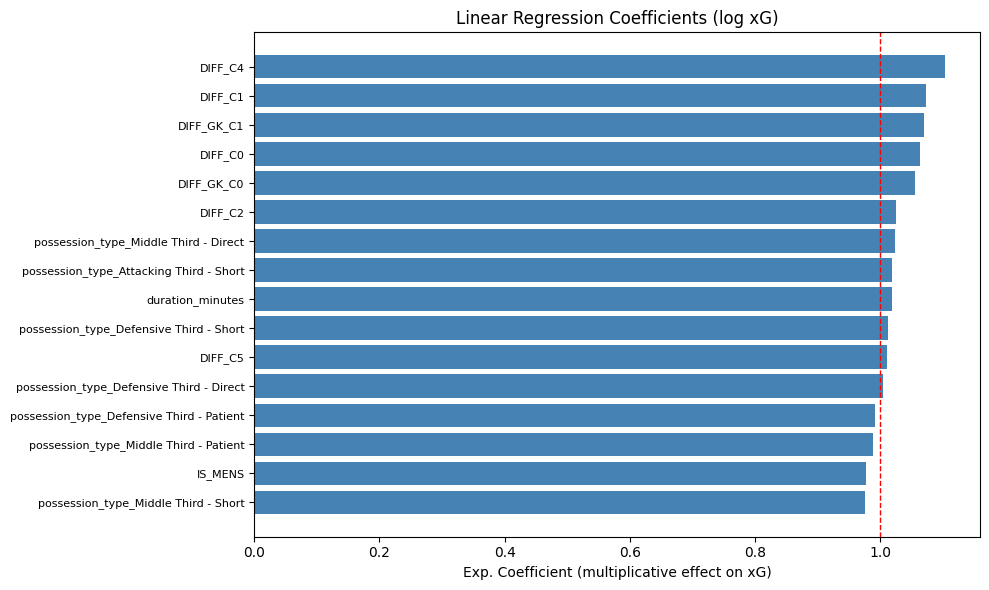

In [12]:
full_plot = results_df.sort_values('exp_coef')

plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['exp_coef'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Exp. Coefficient (multiplicative effect on xG)')
plt.title('Linear Regression Coefficients (log xG)')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Summary

**Summary: We ran a linear regression model predicting log(xG) on shot-producing possessions (n = 77,428), using possession type, lineup composition, goalkeeper archetype differentials, and duration as features. Response variable is log-transformed to address right skew. Exponentiated coefficients represent multiplicative effects on xG.**

Highlights:

* Duration is positive and significant. Longer possessions are associated with slightly higher xG per possession, which lines up with the logistic regression results
* DIFF_C4 is the strongest positive cluster effect (exp coef 1.104). The women's C4 archetype advantage is associated with notably higher xG
* DIFF_C1 is now positive and significant (exp coef 1.073) which is a reversal from previous model versions where it was negative; this change is likely due to the addition of GK features absorbing variance previously loaded onto DIFF_C1
* DIFF_GK_C1 is positive and significant (exp coef 1.069). Having a GK_C1-type goalkeeper advantage over the opponent is associated with higher xG quality
* DIFF_GK_C0 is also positive and significant (exp coef 1.056)
* IS_MENS is negative and significant. Men's possessions are associated with slightly lower xG per shot than women's, all else equal
* Several features are not significant: DIFF_C5 (p=0.091), Defensive Third - Short (p=0.128), Defensive Third - Direct (p=0.651), Defensive Third - Patient (p=0.080)

Model performance stats:

* R^2 of 0.012, which is still stable across 5-fold CV (mean 0.014, std 0.003)
* Low R^2 is somewhat expected: possession style/lineup composition explain a small but statistically significant share of xG variance. The dominant drivers of individual shot quality (typical xG uses shot location, technique, goalkeeper positioning, defensive pressure) are not captured at the possession level
* The model is statistically significant overall (F-statistic p ~ 0)

To note:

* Reference category is "Attacking Third - Patient" throughout
* DIFF columns represent offensive minus defensive player counts per type, w/ C3 and GK_C2 as baseline references
* We filteres the dataset to shot-producing possessions only; zero-xG possessions were excluded by design
* 254 possessions dropped where a substitution occurred mid-possession; the lineup is attributed to the lineup at start of possession
* C4 and C5 represent women's player archetypes; for men's possessions these values are always 0